<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4p/blob/main/05_stan_linreg_1.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(stan-reglin1-notebook)=
# Regressione lineare con Stan

## Preparazione del Notebook

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import arviz as az
import warnings
from cmdstanpy import cmdstan_path, CmdStanModel

/opt/anaconda3/envs/stan_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [112]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

# Imposta la precisione globale a 2 cifre decimali
pd.set_option('display.precision', 2)

Utilizzeremo il modello `bivariate_linreg_model` che può essere usato sia per la regressione bivariata. Il modello Stan assume che tutte le variabili, sia la $y$ sia le $X$ siano standardizzate. Sui parametri del modello ($\alpha$, $\beta$, $\sigma$) sono state imposte delle distribuzioni a priori debolmente informative.

In [113]:
stan_file = os.path.join('stan', 'bivariate_linreg_model.stan')
with open(stan_file, 'r') as f:
    print(f.read())

data {
  int<lower=1> N;
  vector[N] x;
  vector[N] y;
}
parameters {
  real alpha;
  real beta;
  real<lower=0> sigma;
}
model {
  y ~ normal(alpha + beta * x, sigma);
  alpha ~ normal(0, 2.5);
  beta ~ normal(0, 2.5);
  sigma ~ normal(0, 2.5);
}
generated quantities {
  array[N] real y_rep = normal_rng(alpha + beta * x, sigma);
}



Compiliamo il modello.

In [114]:
model = CmdStanModel(stan_file=stan_file)
print(model)

CmdStanModel: name=bivariate_linreg_model
	 stan_file=/Users/corradocaudek/_repositories/ds4p/chapter_5/stan/bivariate_linreg_model.stan
	 exe_file=/Users/corradocaudek/_repositories/ds4p/chapter_5/stan/bivariate_linreg_model
	 compiler_options=stanc_options={}, cpp_options={}


Creiamo il dizionario che contiene i dati richiesti dal modello.

In [115]:
kidiq = pd.read_stata("../data/kidiq.dta")
kidiq.head()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
0,65,1.0,121.12,4,27
1,98,1.0,89.36,4,25
2,85,1.0,115.44,4,27
3,83,1.0,99.45,3,25
4,115,1.0,92.75,4,27


In [116]:
x = stats.zscore(kidiq["mom_iq"])
y = stats.zscore(kidiq["kid_score"])

In [117]:
print(np.mean(x), np.std(x))

4.9115857310606007e-17 0.9999999999999999


I dati devono essere contenuti in un dizionario. Nel caso presente, il dizionario `data` può essere creato nel modo seguente.

In [118]:
stan_data = {
    "N" : len(x),
    "x" : x,
    "y" : y 
}

Eseguiamo il campionamento MCMC.

In [119]:
fit = model.sample(data=stan_data)

06:48:39 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status




chain 1 |██████▎   | 00:00 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████████| 00:00 Sampling completed                       
chain 2 |██████████| 00:00 Sampling completed                       
chain 3 |██████████| 00:00 Sampling completed                       
chain 4 |██████████| 00:00 Sampling completed                       


06:48:39 - cmdstanpy - INFO - CmdStan done processing.
06:48:39 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bivariate_linreg_model.stan', line 12, column 2 to column 38)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bivariate_linreg_model.stan', line 12, column 2 to column 38)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'bivariate_linreg_model.stan', line 12, column 2 to column 38)
Consider re-running with show_console=True if the above output is unclear!


Esaminiamo i risultati ottenuti.

In [122]:
print(fit.summary())

                Mean      MCSE  StdDev      5%       50%     95%    N_Eff  \
lp__       -1.70e+02  2.99e-02    1.26 -172.44 -1.70e+02 -168.68  1767.76   
alpha      -8.30e-04  6.45e-04    0.04   -0.07 -1.20e-03    0.07  4402.82   
beta        4.48e-01  7.19e-04    0.04    0.38  4.48e-01    0.52  3651.27   
sigma       8.98e-01  4.79e-04    0.03    0.85  8.98e-01    0.95  4075.94   
y_rep[1]    6.66e-01  1.43e-02    0.90   -0.81  6.68e-01    2.15  3961.32   
...              ...       ...     ...     ...       ...     ...      ...   
y_rep[430] -4.57e-01  1.40e-02    0.89   -1.91 -4.42e-01    0.99  4013.63   
y_rep[431] -2.18e-01  1.39e-02    0.90   -1.69 -2.20e-01    1.25  4174.13   
y_rep[432] -1.24e-01  1.38e-02    0.90   -1.59 -1.15e-01    1.34  4266.88   
y_rep[433] -1.00e-01  1.43e-02    0.90   -1.59 -1.05e-01    1.37  3927.98   
y_rep[434] -2.83e-01  1.44e-02    0.91   -1.78 -2.74e-01    1.21  4000.54   

            N_Eff/s  R_hat  
lp__        2770.79    1.0  
alpha       6900.

In [70]:
print(fit.diagnose())

Processing csv files: /var/folders/s7/z86r4t9j6yx376cm120nln6w0000gn/T/tmp6ipuyft3/bivariate_linreg_model7f29pa12/bivariate_linreg_model-20240313062958_1.csv, /var/folders/s7/z86r4t9j6yx376cm120nln6w0000gn/T/tmp6ipuyft3/bivariate_linreg_model7f29pa12/bivariate_linreg_model-20240313062958_2.csv, /var/folders/s7/z86r4t9j6yx376cm120nln6w0000gn/T/tmp6ipuyft3/bivariate_linreg_model7f29pa12/bivariate_linreg_model-20240313062958_3.csv, /var/folders/s7/z86r4t9j6yx376cm120nln6w0000gn/T/tmp6ipuyft3/bivariate_linreg_model7f29pa12/bivariate_linreg_model-20240313062958_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.



L'oggetto `fit` generato da `cmdstanpy` appartiene alla classe `cmdstanpy.stanfit.mcmc.CmdStanMCMC`. Questo oggetto è funzionalmente equivalente a un oggetto della classe `InferenceData`, permettendo quindi la sua manipolazione tramite le funzioni fornite da ArviZ.

In [123]:
az.summary(fit, var_names=(["alpha", "beta", "sigma"]), hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.00e-03,0.04,-0.08,0.08,1.00e-03,1.00e-03,4397.0,3212.0,1.0
beta,4.48e-01,0.04,0.37,0.53,1.00e-03,1.00e-03,3816.0,2607.0,1.0
sigma,8.98e-01,0.03,0.84,0.96,0.00e+00,0.00e+00,4080.0,2798.0,1.0


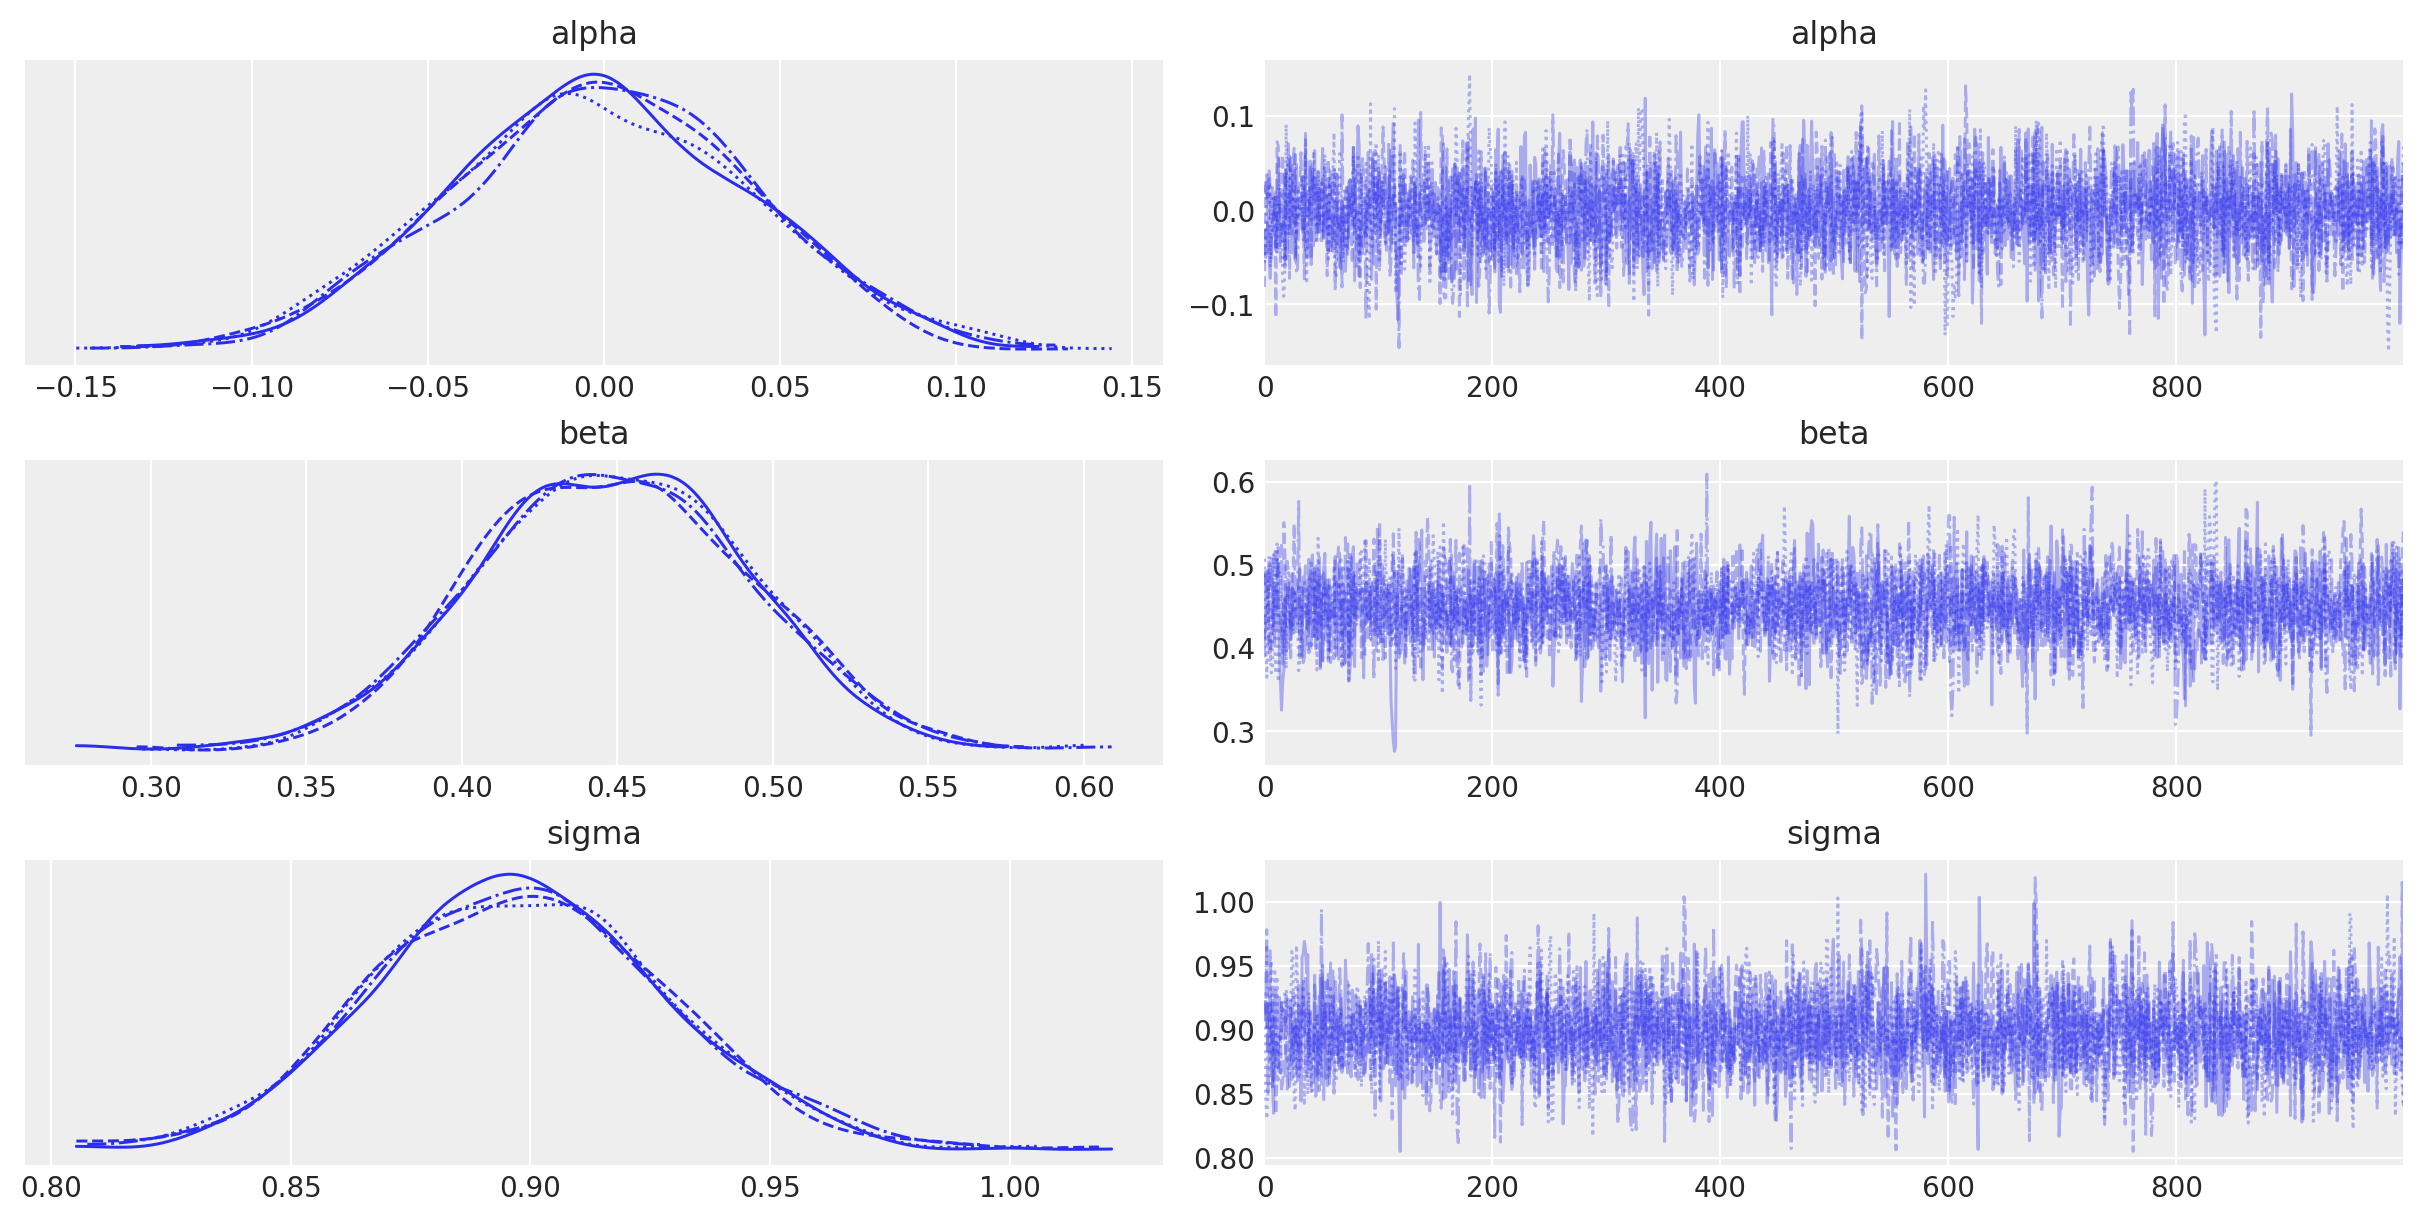

In [124]:
_ = az.plot_trace(fit, var_names=(["alpha", "beta", "sigma"]))

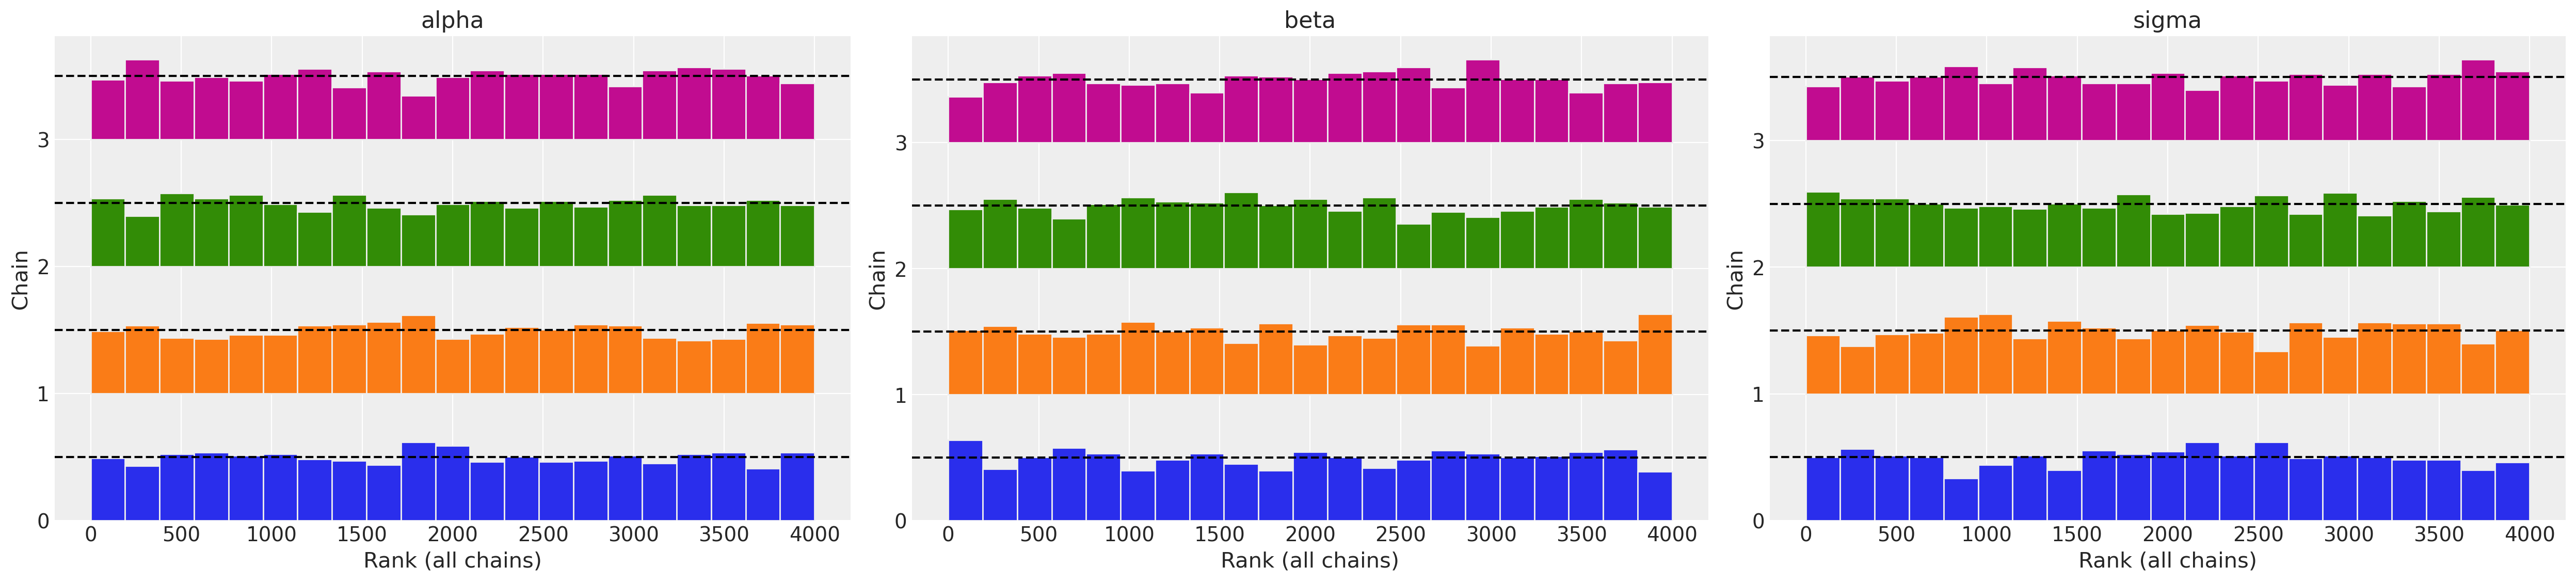

In [23]:
_ = az.plot_rank(fit, var_names=(["alpha", "beta", "sigma"]), kind="bars")

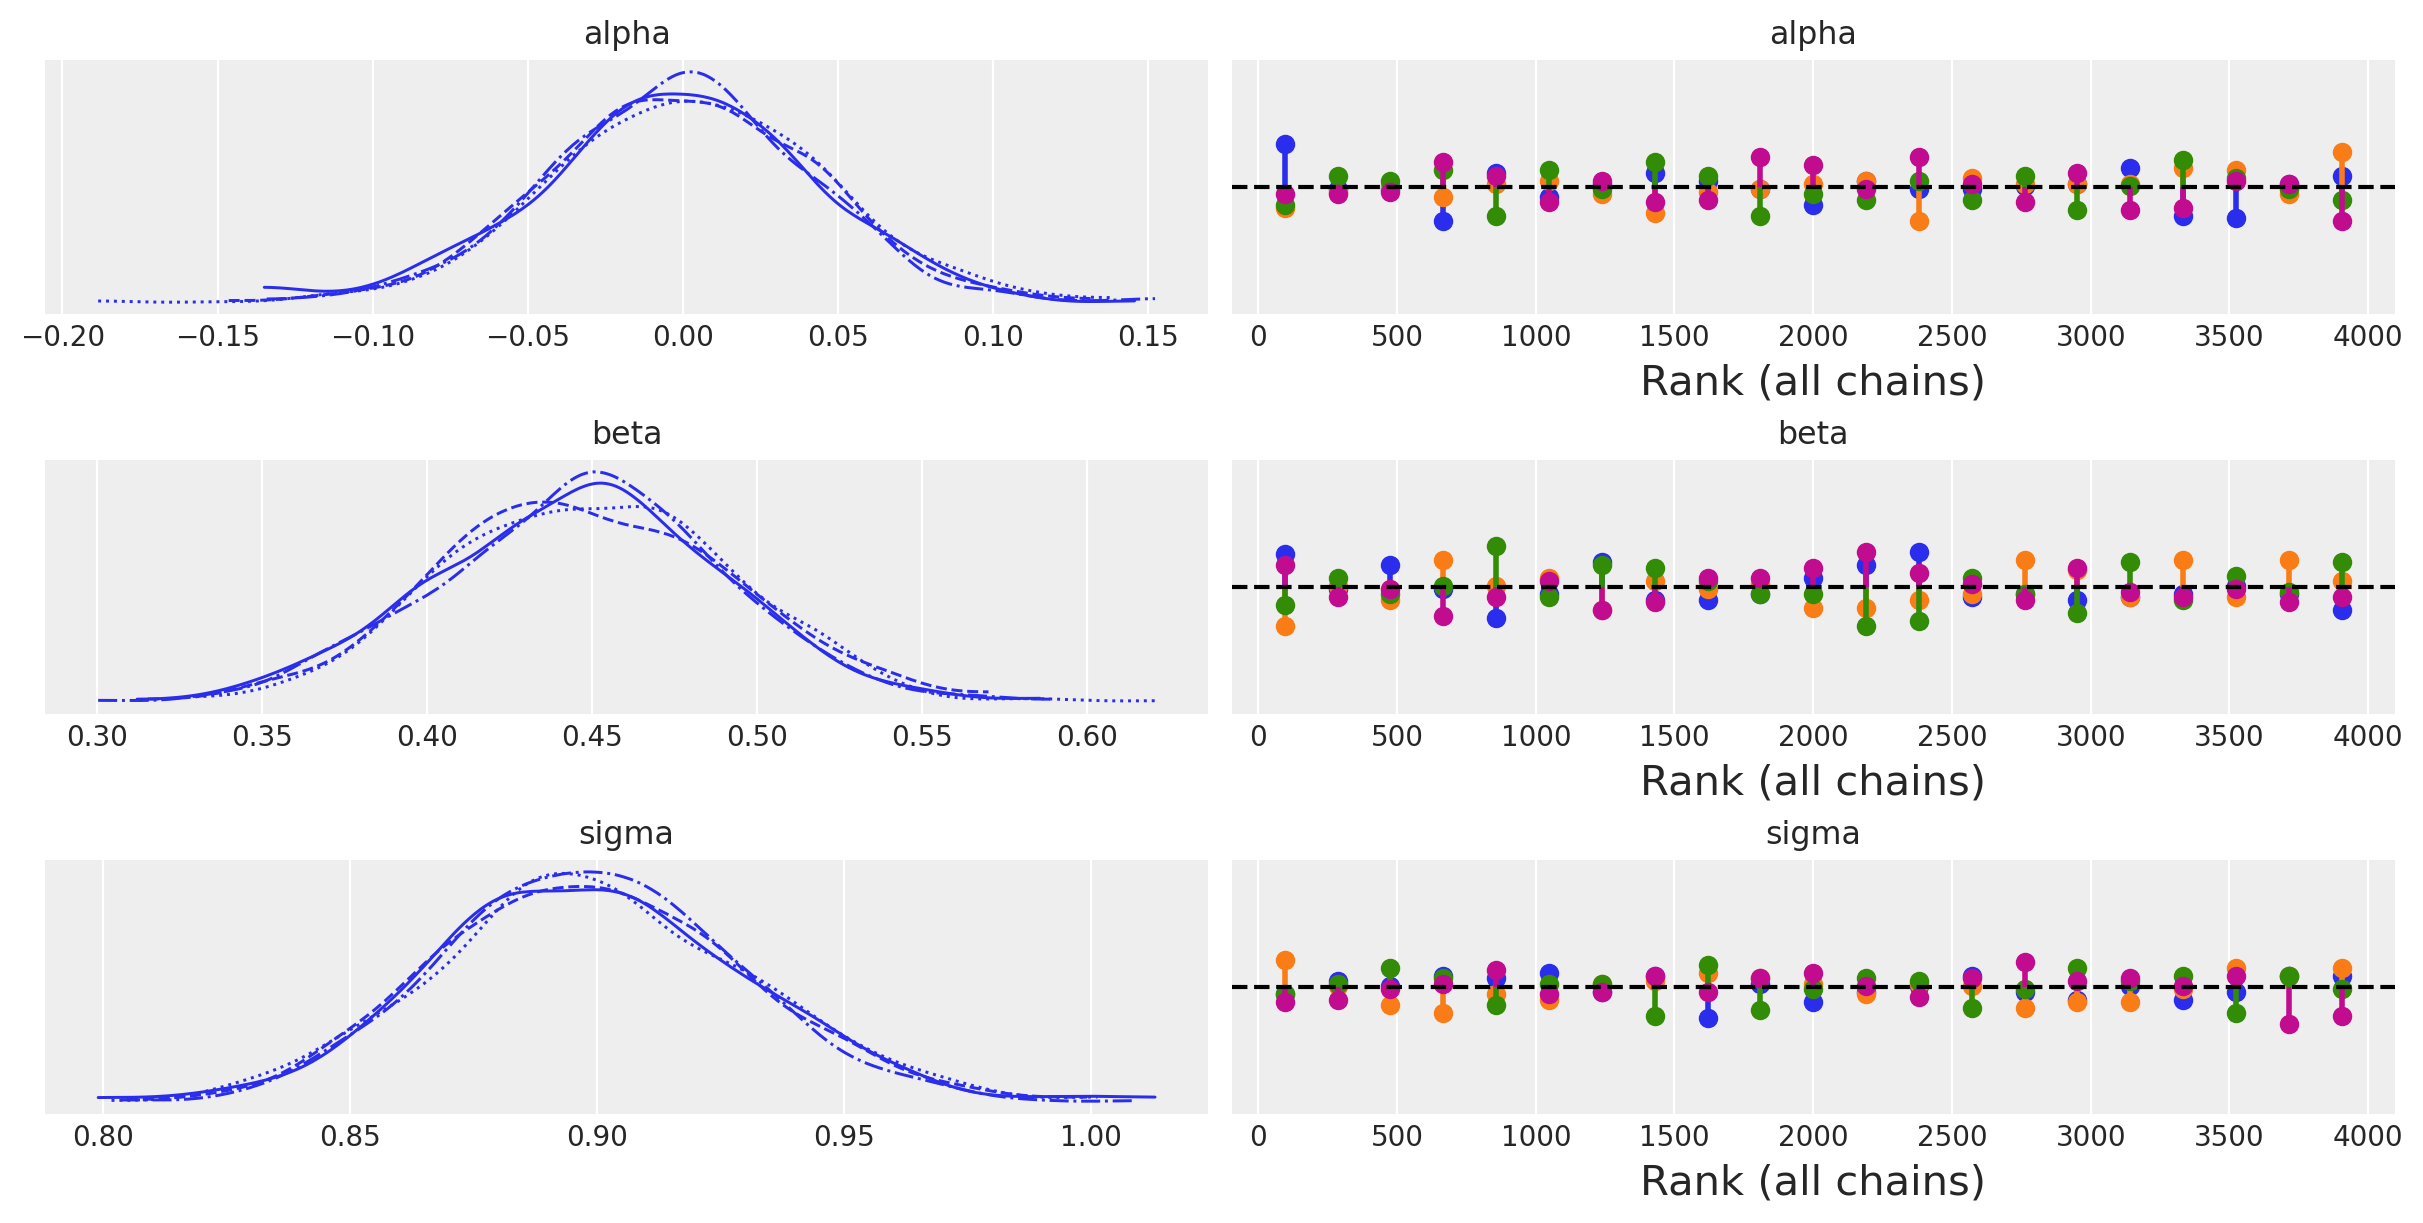

In [45]:
_ = az.plot_trace(fit, var_names=(["alpha", "beta", "sigma"]), kind="rank_vlines")

Alla media della distribuzione a posteriore del parametro $\beta$ assegnamo la solita interpretazione: all'aumentare dell'intelligenza della madre di una deviazione standard, il valore atteso dell'intelligenza del figlio aumenta di 0.45 deviazioni standard, 95% CI [0.36, 0.53]. L'errore standard della regressione è piuttosto grande, con $\sigma_E$ = 0.90.

Possiamo convertire l'oggetto `fit` in un oggetto di classe InferenceData nel modo seguente:

In [46]:
post = az.convert_to_inference_data(fit)
post

Inference data with groups:
	> posterior
	> sample_stats

Per creare un PPC plot dobbiamo innanzitutto creare un oggetto InferenceData nel quale i dati sono strutturati come si aspetta Arviz:

In [47]:
idata = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive='y_rep',
    observed_data={'y': stats.zscore(kidiq["kid_score"])},
)

/opt/anaconda3/envs/stan_env/lib/python3.12/site-packages/arviz/plots/ppcplot.py:267: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten_pp = list(predictive_dataset.dims.keys())
/opt/anaconda3/envs/stan_env/lib/python3.12/site-packages/arviz/plots/ppcplot.py:271: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten = list(observed_data.dims.keys())


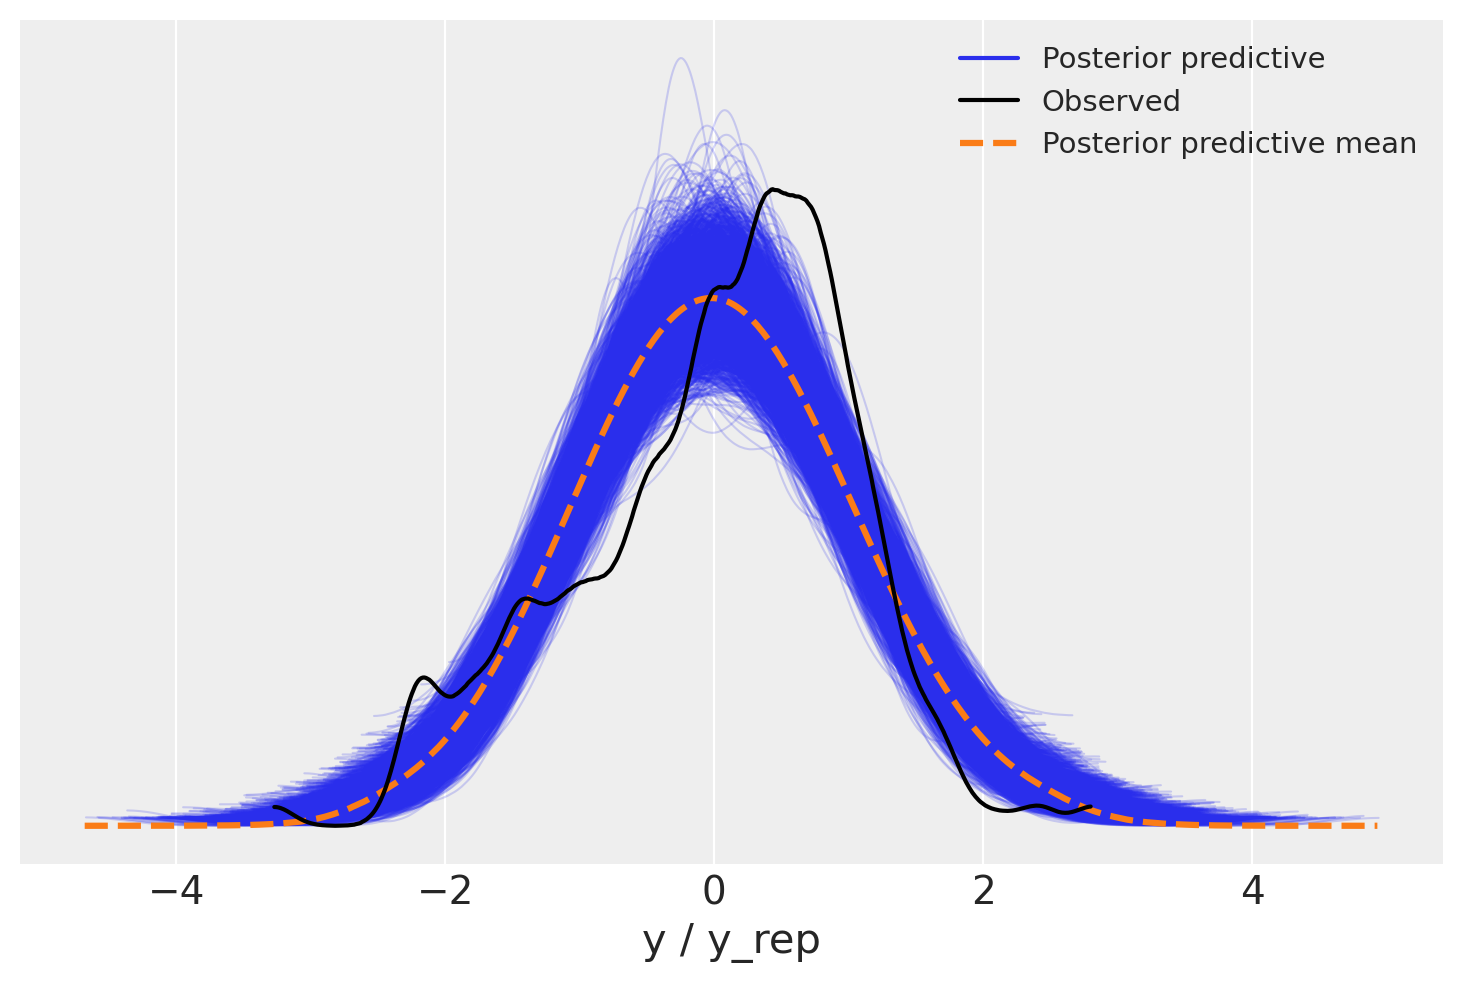

In [48]:
_ = az.plot_ppc(idata, data_pairs={'y': 'y_rep'})

## Regressione multipla

È facile estendere il modello al caso in cui consideriamo predittori multipli dell'intelligenza del bambino. È sufficiente creare una matric $X$ che contiene le colonne che corrispondono ai vari predittori che vogliamo considerare. In qusto esempio, utilizzeremo come preditori dell'intelligenza del figlio, la scolarità della madre (codificata com 0 e 1, per avere o non avere completato le scuole superiori), l'intelligenza della madre e l'età della madre. Tutte le variabili vengono standardizzate prima di procedere con l'analisi.

Consideriamo in dettaglio la verosimiglianza `alpha + X * beta` nel caso in cui $X$ è una matrice con più di un predittore.

Prima di tutto, definiamo le variabili coinvolte:

- `y`: è il vettore delle osservazioni, dove ogni elemento rappresenta un dato osservato.
- `alpha`: è l'intercetta del modello lineare, un singolo valore che rappresenta il punto in cui la linea del modello incrocia l'asse y quando tutte le variabili indipendenti (`X`) sono zero.
- `X`: è la matrice dei predittori (o variabili indipendenti), dove ogni riga corrisponde a un'osservazione e ogni colonna a una variabile indipendente.
- `beta`: è il vettore dei coefficienti, dove ogni elemento rappresenta l'effetto di una corrispondente variabile indipendente in `X` sulla variabile dipendente `y`.
- `sigma`: è la deviazione standard degli errori del modello, che misura quanto i dati reali si discostano dalla linea del modello.

L'espressione `alpha + X * beta` calcola i valori previsti (`y` predetti) per il modello lineare. Ecco come funziona, spiegato senza ricorrere all'algebra matriciale:

1. **Multiplicazione `X * beta`**: Per ogni riga in `X` (che rappresenta un'osservazione con le sue variabili indipendenti), moltiplichiamo ogni elemento (ogni variabile indipendente) per il corrispondente elemento in `beta` (il coefficiente della variabile) e sommiamo questi prodotti. Questo ci dà un valore singolo per ogni osservazione, che rappresenta il contributo combinato di tutte le variabili indipendenti alla variabile dipendente, prima di aggiungere l'intercetta.

2. **Aggiunta di `alpha`**: Dopo aver calcolato il contributo combinato delle variabili indipendenti, aggiungiamo l'intercetta (`alpha`) a questo valore. L'intercetta rappresenta il valore di `y` quando tutte le variabili indipendenti sono zero. Aggiungendola, otteniamo il valore previsto finale per `y` per ogni osservazione.

3. **Risultato**: L'espressione `alpha + X * beta` produce quindi un vettore di valori previsti di dimensione $n \times 1$, dove $n$ è il numero di osservazioni in `y`. Ogni elemento di questo vettore è il valore previsto di `y` per ogni osservazione, dato il modello lineare specificato.

Per fare un esempio semplice, immaginiamo di avere un modello con una sola variabile indipendente per semplificare:

- Supponiamo che `alpha` sia 5 (l'intercetta).
- La matrice `X` ha una sola colonna (una sola variabile indipendente) con, per esempio, tre osservazioni: `[1, 2, 3]`.
- Il vettore `beta` ha un solo elemento, diciamo 2, che è il coefficiente della nostra variabile indipendente.

Per ogni osservazione in `X`, moltiplichiamo il suo valore per `beta` (2 in questo caso) e aggiungiamo `alpha` (5). Quindi, per la prima osservazione (1), otteniamo $1 \times 2 + 5 = 7$, e così via per le altre osservazioni. Il risultato finale è un vettore di valori previsti di `y`.


Espandiamo ora l'esempio precedente per un caso di regressione multipla, dove abbiamo due variabili indipendenti (predittori). Questo ci permetterà di vedere come il processo di calcolo dei valori previsti si adatta quando ci sono più predittori nel modello.

- `alpha`: l'intercetta del modello, diciamo che è 5.
- `X`: la matrice dei predittori ora ha due colonne, perché abbiamo due variabili indipendenti. Per esempio, possiamo avere tre osservazioni come segue:

  $$
  X = \begin{bmatrix}
  1 & 3 \\
  2 & 2 \\
  3 & 1 \\
  \end{bmatrix}
  $$

  Qui, ogni riga rappresenta un'osservazione e ogni colonna rappresenta una variabile indipendente. Ad esempio, la prima riga rappresenta una osservazione dove il primo predittore ha valore 1 e il secondo predittore ha valore 3.

- `beta`: il vettore dei coefficienti ora ha due elementi, uno per ogni variabile indipendente. Supponiamo che `beta = [2, 1]`, dove 2 è il coefficiente per il primo predittore e 1 è il coefficiente per il secondo predittore.
- `sigma`: la deviazione standard degli errori del modello, che per semplicità non utilizzeremo direttamente in questo esempio.

Per calcolare i valori previsti (`y` predetti) per ogni osservazione, seguiamo questi passi:

1. **Moltiplicazione `X * beta`**:

   - Per la prima osservazione (`[1, 3]`), calcoliamo: $1 \times 2 + 3 \times 1 = 2 + 3 = 5$.
   - Per la seconda osservazione (`[2, 2]`), calcoliamo: $2 \times 2 + 2 \times 1 = 4 + 2 = 6$.
   - Per la terza osservazione (`[3, 1]`), calcoliamo: $3 \times 2 + 1 \times 1 = 6 + 1 = 7$.

   Questo passo ci dà il contributo combinato delle variabili indipendenti alla variabile dipendente per ogni osservazione.

2. **Aggiunta di `alpha`**:

   - Aggiungiamo l'intercetta `alpha` (5) ai risultati precedenti per ottenere i valori previsti finali di `y`:

     - Prima osservazione: $5 + 5 = 10$.
     - Seconda osservazione: $6 + 5 = 11$.
     - Terza osservazione: $7 + 5 = 12$.

3. **Risultato**:

   Otteniamo quindi un vettore di valori previsti di `y` di dimensione $n \times 1$, dove $n$ è il numero di osservazioni. In questo caso, il vettore dei valori previsti di `y` sarà `[10, 11, 12]`.

Questo esempio illustra come l'espressione `alpha + X * beta` in un contesto di regressione multipla produca un vettore di valori previsti. Ogni valore previsto è il risultato della somma del prodotto dei predittori per i loro rispettivi coefficienti più l'intercetta, riflettendo come il modello lineare stima `y` in base ai valori di più variabili indipendenti.

In [126]:
stan_file = os.path.join('stan', 'linear_regression.stan')
with open(stan_file, 'r') as f:
    print(f.read())

// run with 4 chains and 2k iters.
// all data should be scaled to mean 0 and std 1:
data {
  int<lower=1> N;   // number of observations
  int<lower=1> K;   // number of independent variables, including the intercept
  matrix[N, K] X;   // data matrix
  vector[N] y;      // dependent variable vector
}
parameters {
  real alpha;           // intercept
  vector[K] beta;       // coefficients for independent variables
  real<lower=0> sigma;  // model error
}
model {
  // priors
  alpha ~ student_t(3, 0, 2.5);
  beta ~ student_t(3, 0, 2.5);
  sigma ~ exponential(1);

  // likelihood
  y ~ normal(alpha + X * beta, sigma);
}
generated quantities {
  vector[N] log_lik; // Log-likelihood for each observation
  vector[N] y_rep;  // Posterior predictions for each observation

  for (n in 1:N) {
    log_lik[n] = normal_lpdf(y[n] | alpha + dot_product(X[n], beta), sigma);
    y_rep[n] = normal_rng(alpha + dot_product(X[n], beta), sigma);
  }
}



In [127]:
model = CmdStanModel(stan_file=stan_file)
print(model)

CmdStanModel: name=linear_regression
	 stan_file=/Users/corradocaudek/_repositories/ds4p/chapter_5/stan/linear_regression.stan
	 exe_file=/Users/corradocaudek/_repositories/ds4p/chapter_5/stan/linear_regression
	 compiler_options=stanc_options={}, cpp_options={}


In [128]:
x1 = stats.zscore(kidiq["mom_hs"])
x2 = stats.zscore(kidiq["mom_iq"])
x3 = stats.zscore(kidiq["mom_age"])

In [129]:
df = pd.DataFrame({
    "one": [1] * len(x1),  # Crea una lista di 1 della stessa lunghezza di x1
    "x1": x1,
    "x2": x2,
    "x3": x3
})

df.head()

,one,x1,x2,x3
0,1,0.52,1.41,1.56
1,1,0.52,-0.71,0.82
2,1,0.52,1.03,1.56
3,1,0.52,-0.04,0.82
4,1,0.52,-0.48,1.56


In [130]:
# Convert scaled DataFrame to numpy matrix
X = df.to_numpy()

In [131]:
# Verificare le dimensioni di X
print("Dimensioni di X:", X.shape)

Dimensioni di X: (434, 4)


In [133]:
stan_data = {
    "N": X.shape[0],
    "K": X.shape[1],  # Nota: questa include anche la colonna dell'intercetta 
    "X": X,
    "y": stats.zscore(kidiq["kid_score"])  # Assumo che kid_score sia la variabile dipendente
}

In [134]:
fit2 = model.sample(data=stan_data)

06:50:14 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status





chain 1 |█▎        | 00:00 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |██▎       | 00:00 Iteration:  300 / 2000 [ 15%]  (Warmup)

chain 1 |███▏      | 00:00 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 00:00 Iteration:  600 / 2000 [ 30%]  (Warmup)


chain 1 |████      | 00:01 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |████▌     | 00:01 Iteration:  800 / 2000 [ 40%]  (Warmup)




chain 1 |█████     | 00:01 Iteration:  900 / 2000 [ 45%]  (Warmup)
chain 1 |█████▉    | 00:01 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 00:01 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 00:01 Iteration: 1200 / 2000 [ 60%]  (Sampling)


chain 1 |███████▎  | 00:02 Iteration: 1300 / 2000 [ 65%]  (Sampling)

chain 1 |███████▋  | 00:02 Iteration: 1400 / 2000 [ 70%]  (Sampling)


chain 1 |████████▏ | 00:02 Iteration: 1500 / 2000 [ 75%]  (Sampling)


chain 1 |████████▋ | 00:02 Iteration: 1600 / 2000 [ 80%]  (Sampling)
chain 1 |█████████ | 00


06:50:18 - cmdstanpy - INFO - CmdStan done processing.


In [135]:
post = az.convert_to_inference_data(fit2)
post

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [136]:
az.summary(fit2, var_names=(["alpha", "beta", "sigma"]), hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,4.00e-03,1.91,-3.55,4.02,4.40e-02,3.80e-02,1946.0,1691.0,1.0
beta[0],-5.00e-03,1.91,-4.01,3.58,4.40e-02,3.80e-02,1941.0,1676.0,1.0
beta[1],1.13e-01,0.05,0.02,0.20,1.00e-03,1.00e-03,3318.0,2721.0,1.0
beta[2],4.12e-01,0.04,0.33,0.50,1.00e-03,1.00e-03,3161.0,2596.0,1.0
beta[3],3.00e-02,0.04,-0.06,0.12,1.00e-03,1.00e-03,3404.0,2518.0,1.0
sigma,8.92e-01,0.03,0.83,0.95,1.00e-03,0.00e+00,3133.0,2630.0,1.0


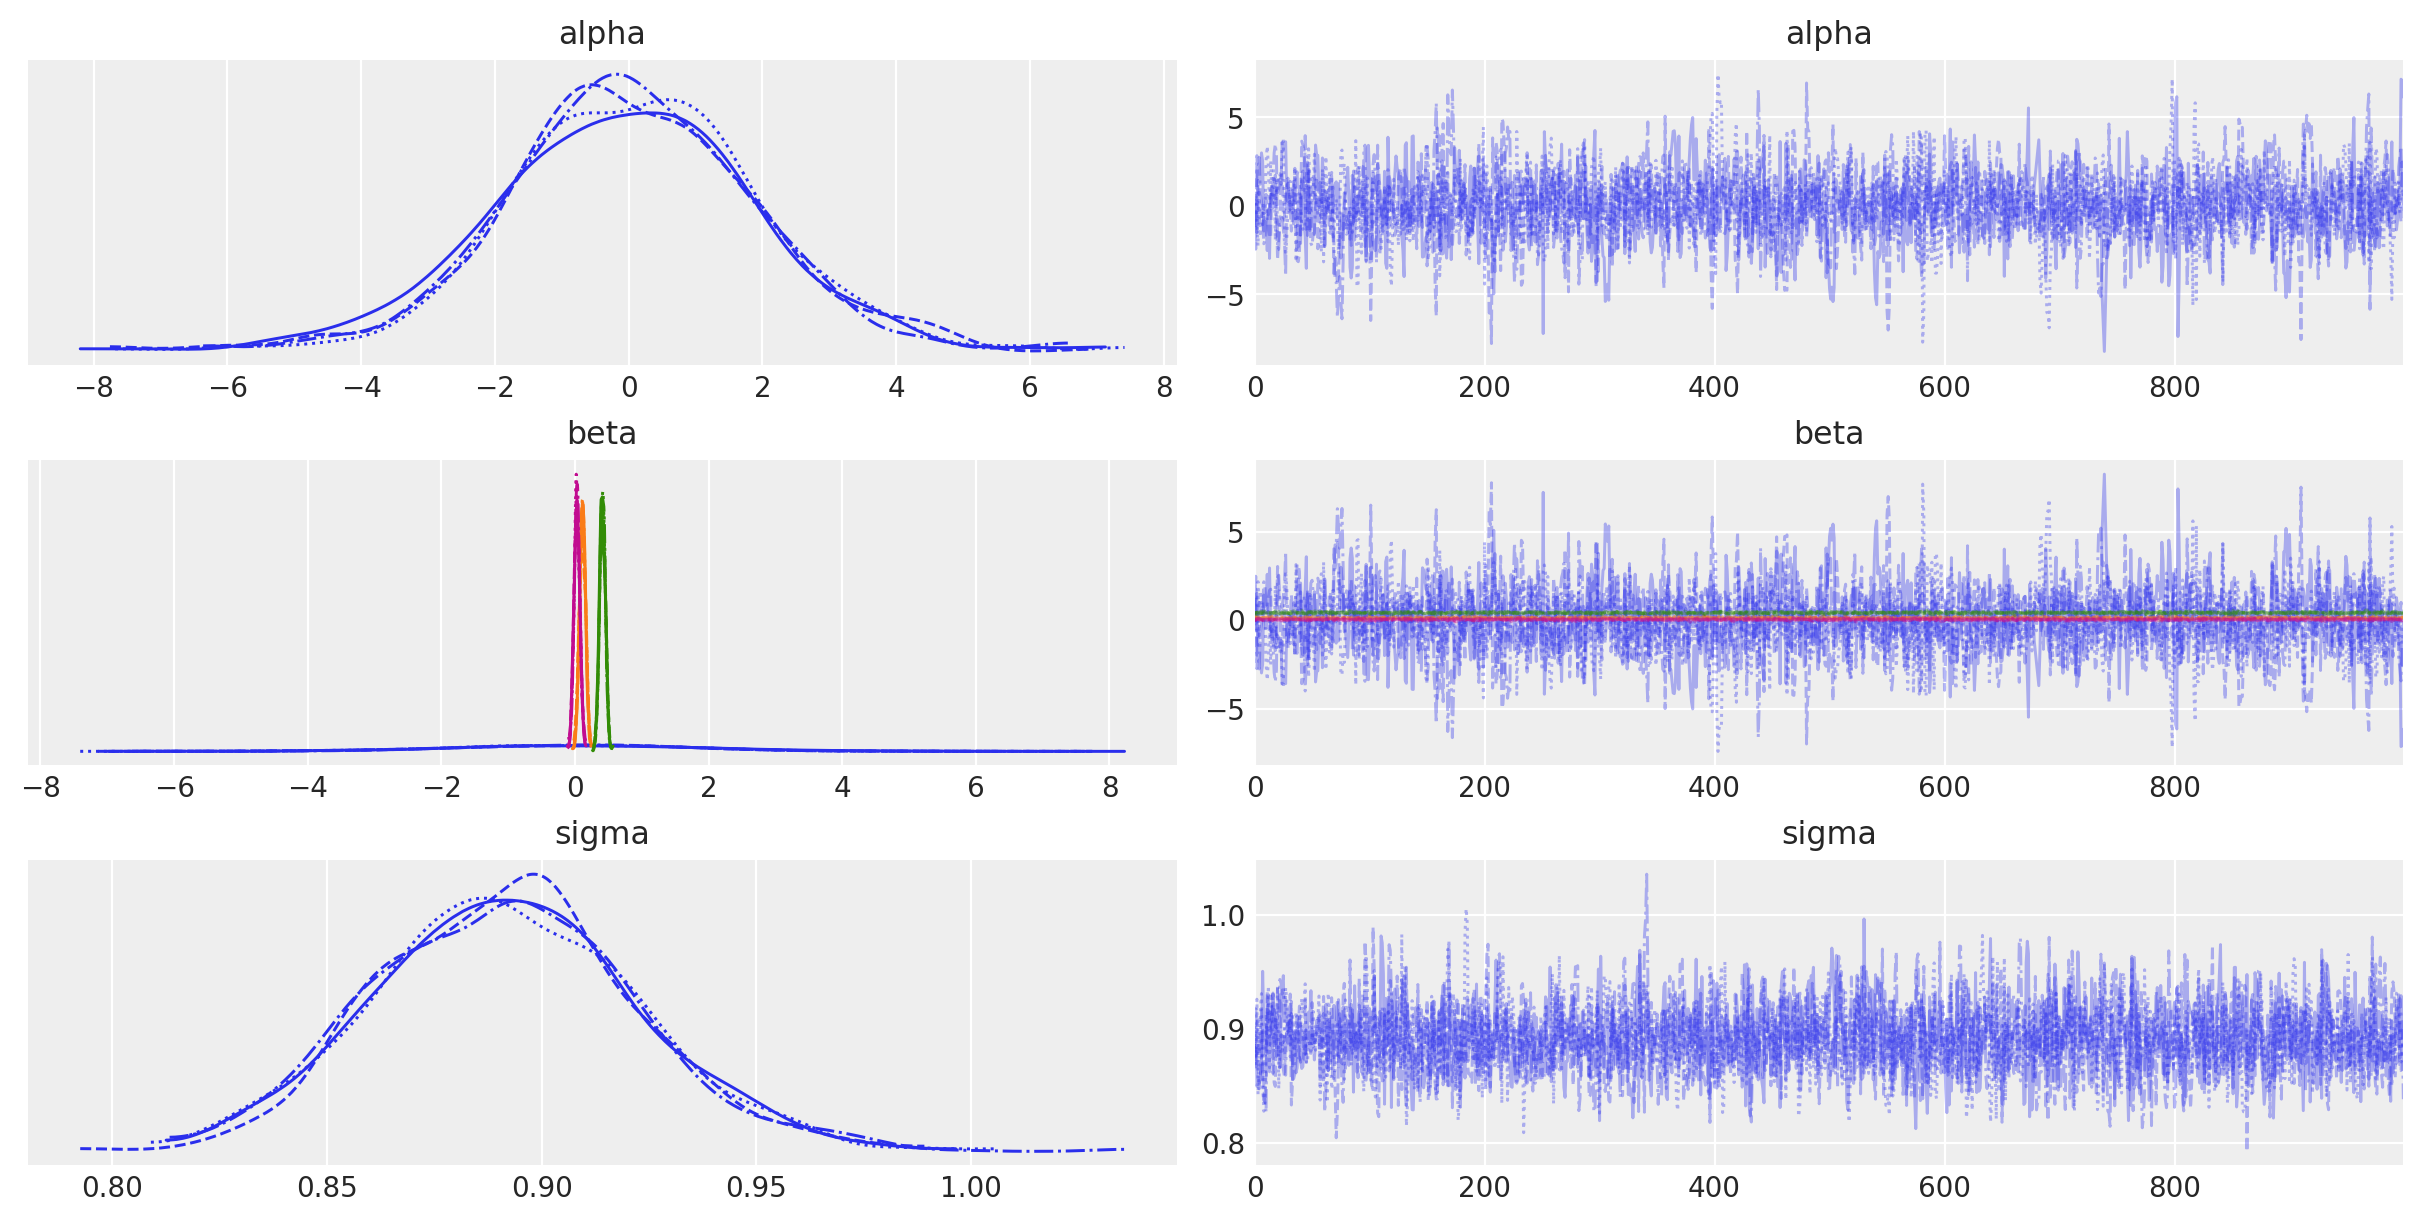

In [138]:
_ = az.plot_trace(fit2, var_names=(["alpha", "beta", "sigma"]))

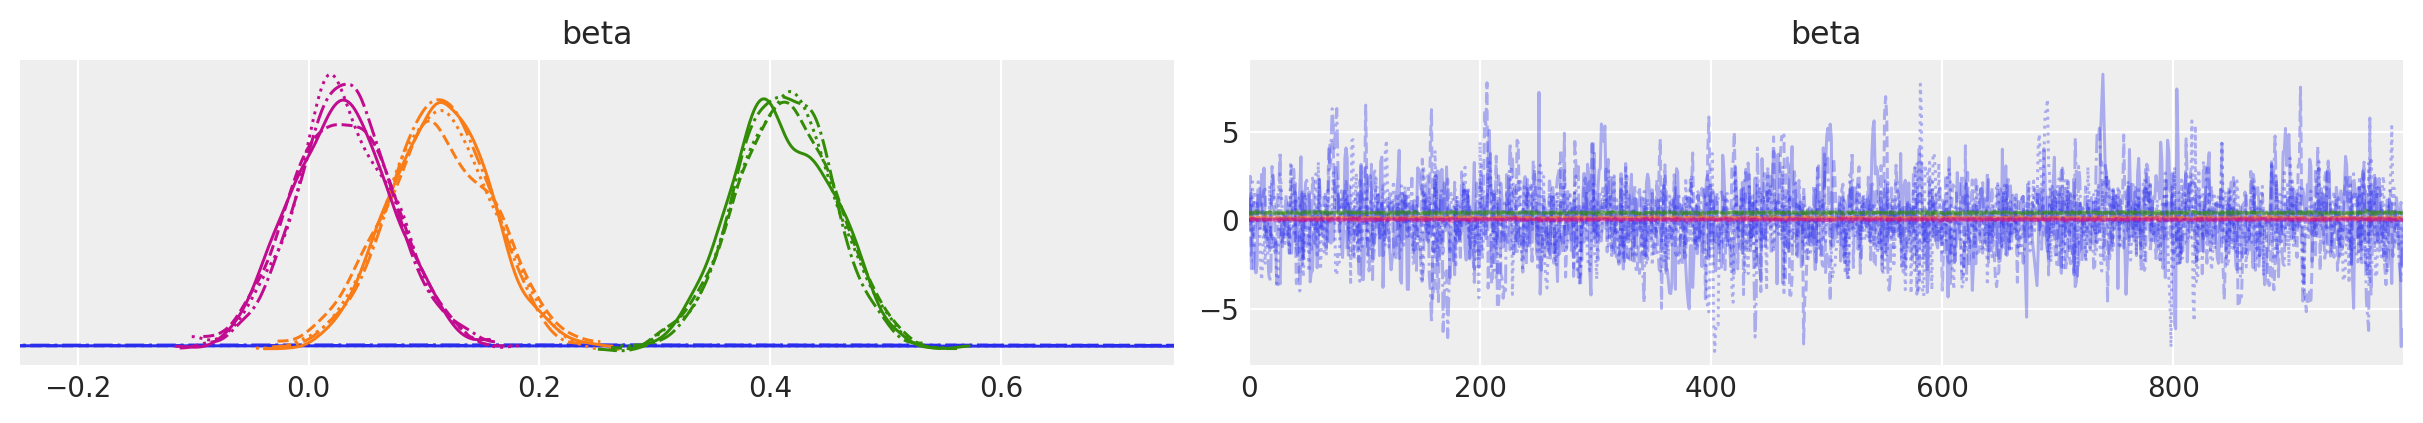

In [145]:
# Zoom in 
axes = az.plot_trace(fit2, var_names=["beta"])

for ax_row in axes:
    ax_row[0].set_xlim(-0.25, 0.75)  # Modifica solo l'asse del grafico della densità

plt.show()

Nel contesto della regressione multivariata, l'interpretazione dei coefficienti parziali differisce da quella della regressione bivariata. Nel nostro caso, il coefficiente associato all'intelligenza della madre, indicato come $\beta$ = 0.41, assume il seguente significato: prevediamo che l'intelligenza del bambino aumenti di 0.41 deviazioni standard in media per ogni deviazione standard aggiuntiva nell'intelligenza della madre, mantenendo costanti gli effetti del livello di istruzione e dell'età della madre. Questo implica che stiamo considerando l'impatto dell'intelligenza della madre sull'intelligenza del bambino all'interno di una popolazione di madri che sono omogenee per quanto riguarda il livello di istruzione e l'età.

In [140]:
idata2 = az.from_cmdstanpy(
    posterior=fit2,
    posterior_predictive='y_rep',
    observed_data={'y': stats.zscore(kidiq["kid_score"])},
)

/opt/anaconda3/envs/stan_env/lib/python3.12/site-packages/arviz/plots/ppcplot.py:267: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten_pp = list(predictive_dataset.dims.keys())
/opt/anaconda3/envs/stan_env/lib/python3.12/site-packages/arviz/plots/ppcplot.py:271: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten = list(observed_data.dims.keys())


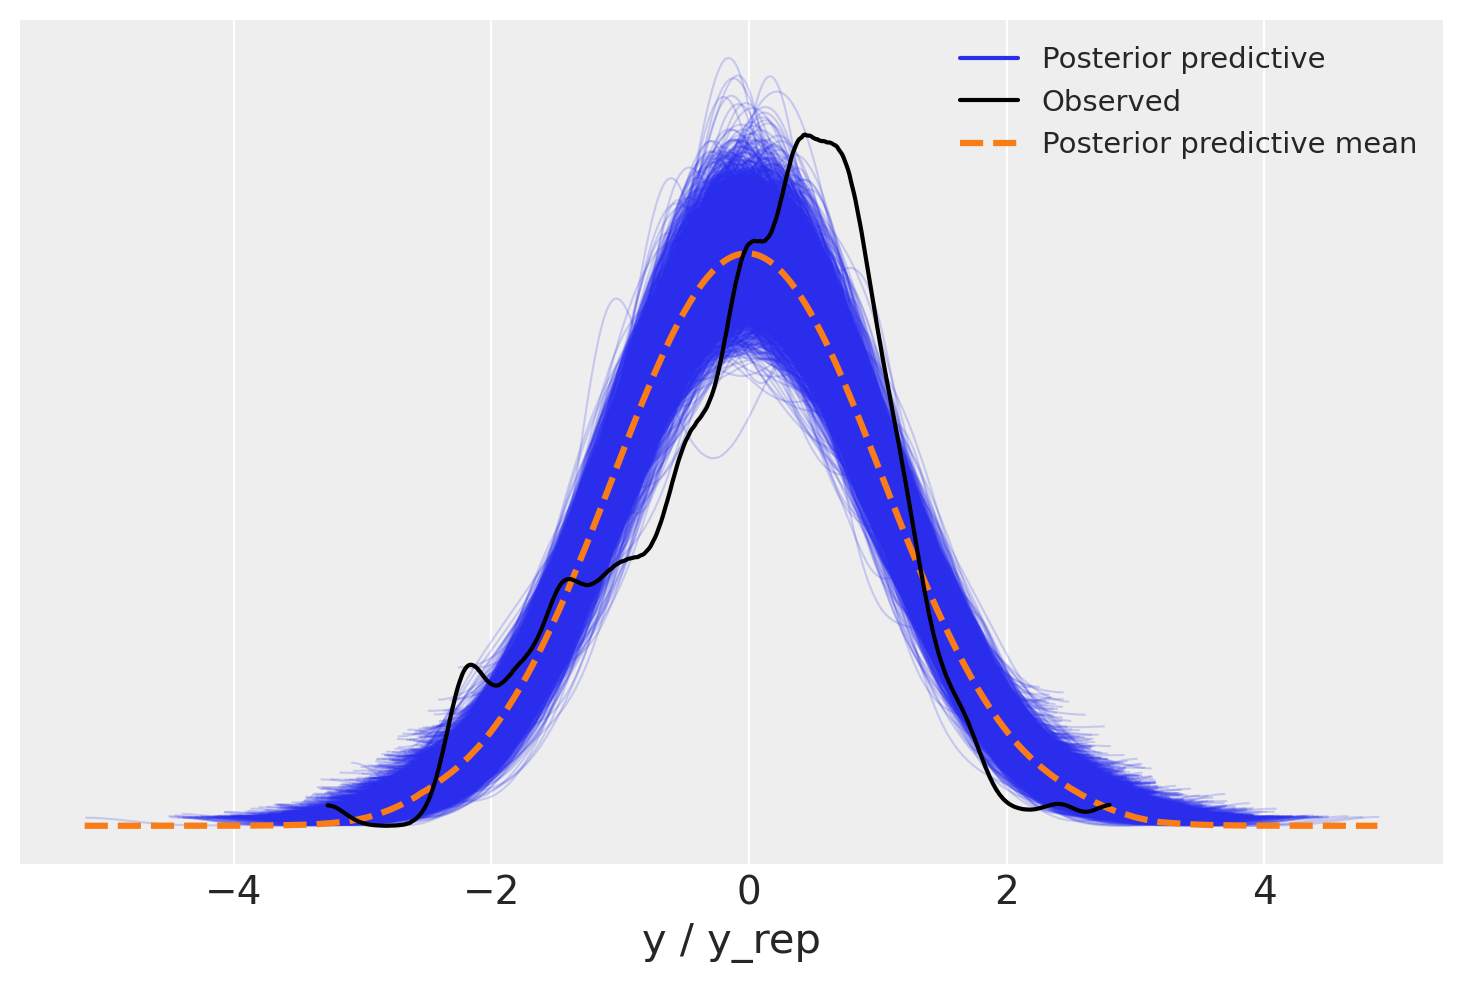

In [141]:
_ = az.plot_ppc(idata2, data_pairs={'y': 'y_rep'})

## Watermark

In [111]:
%load_ext watermark
%watermark -n -u -v -iv -w -m -p cmdstanpy

Last updated: Wed Mar 13 2024

Python implementation: CPython
Python version       : 3.12.2
IPython version      : 8.22.2

cmdstanpy: 1.2.1

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

numpy     : 1.26.4
matplotlib: 3.8.3
pandas    : 2.2.1
scipy     : 1.12.0
seaborn   : 0.13.2
arviz     : 0.17.0

Watermark: 2.4.3

